In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import warnings
import json
import os
warnings.filterwarnings('ignore')

# Identified parameters from phys_14_drone.ipynb
c1 = -8.29151533
c2 = 0.00418887
c3 = -1.43673669

# Bounds
u_min, u_max = -100.0, 100.0
Ts = 0.05  # Sampling time


Soma real dos polos projetada: -1.4367 (Deve ser = -1.4367)
Analytical PI Design Summary:
------------------------------------------------------------
Angle   0 deg | Kp=-1796.6, Ki= 44.0
Angle  30 deg | Kp=-1531.4, Ki= 44.0
Angle  60 deg | Kp=-806.9, Ki= 44.0
Angle  90 deg | Kp= 182.8, Ki= 44.0
Angle 120 deg | Kp=1172.5, Ki= 44.0
Angle 150 deg | Kp=1897.0, Ki= 44.0
Angle 180 deg | Kp=2162.2, Ki= 44.0


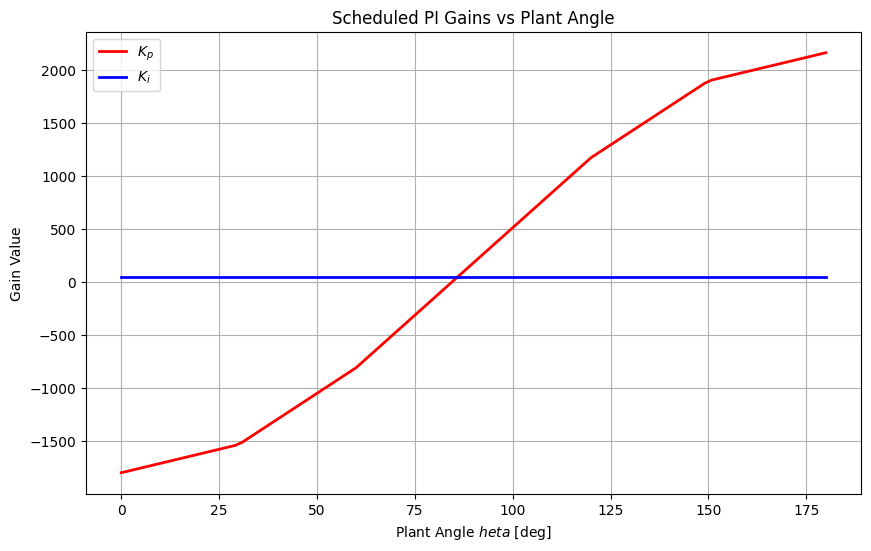

In [2]:
angles_deg = np.array([0, 30, 60, 90, 120, 150, 180], dtype=float)
angles_rad = np.deg2rad(angles_deg)

v_eq_list = []
Kp_list, Ki_list = [], []

# =========================================================================
# PI POLE PLACEMENT
# A malha fechada tem equação característica:
# s^3 - c3*s^2 + (c2*Kp - c1*cos(th))*s + c2*Ki = 0
# A soma dos polos (alpha_2) é estritamente -c3 = 1.4367
# =========================================================================
# Vamos escolher um par dominante subamortecido: zeta=0.7, wn=0.5
# (raízes: -0.35 +- j0.357)
# O terceiro polo real DEVE ser: -1.4367 - 2*(-0.35) = -0.7367
# =========================================================================
P_desired = [
    complex(-0.35, 0.357),
    complex(-0.35, -0.357),
    -0.7367
]
alpha = np.poly(P_desired).real  # [1, alpha2, alpha1, alpha0]
alpha2, alpha1, alpha0 = alpha[1], alpha[2], alpha[3]

print(f"Soma real dos polos projetada: {-alpha2:.4f} (Deve ser = {c3:.4f})")

print("Analytical PI Design Summary:")
print("-" * 60)
for th in angles_rad:
    sin_th = np.clip(np.sin(th), 0, None) 
    cos_th = np.cos(th)
    
    # Equilibrium virtual control
    v_eq = (-c1 * sin_th) / c2
    v_eq_list.append(v_eq)
    
    # Analytical PI matching:
    Kp_opt = (alpha1 + c1 * cos_th) / c2
    Ki_opt = alpha0 / c2
    
    Kp_list.append(Kp_opt)
    Ki_list.append(Ki_opt)
    
    print(f"Angle {np.rad2deg(th):>3.0f} deg | Kp={Kp_opt:6.1f}, Ki={Ki_opt:5.1f}")

interp_veq = interp1d(angles_deg, v_eq_list, kind='cubic', fill_value='extrapolate')
interp_Kp = interp1d(angles_deg, Kp_list, kind='linear', fill_value='extrapolate')
interp_Ki = interp1d(angles_deg, Ki_list, kind='linear', fill_value='extrapolate')

th_plot = np.linspace(0, 180, 100)
plt.figure(figsize=(10, 6))
plt.plot(th_plot, interp_Kp(th_plot), 'r-', lw=2, label='$K_p$')
plt.plot(th_plot, interp_Ki(th_plot), 'b-', lw=2, label='$K_i$')
plt.title('Scheduled PI Gains vs Plant Angle')
plt.xlabel('Plant Angle $\theta$ [deg]')
plt.ylabel('Gain Value')
plt.legend(); plt.grid(True)
plt.show()


In [3]:
# Salvar os Ganhos em JSON
gains = {
    "SCHED_NODES": angles_deg.tolist(),
    "KP_NODES": Kp_list,
    "KI_NODES": Ki_list,
    "VEQ_NODES": v_eq_list
}
out_path = os.path.join("..", "pi_gains.json")
with open(out_path, "w") as f:
    json.dump(gains, f, indent=4)
print(f"Ganhos PI salvos em {out_path}")


Ganhos PI salvos em ../pi_gains.json


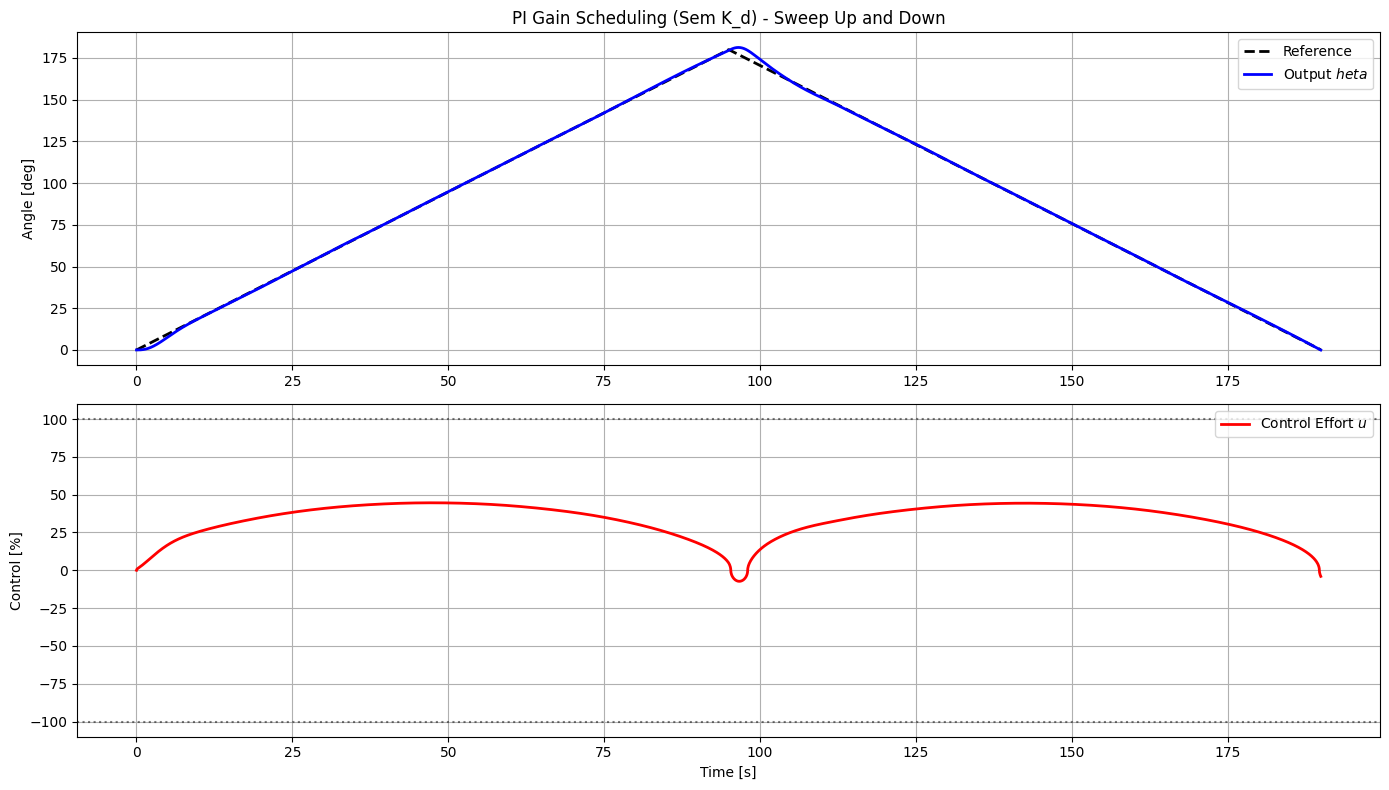

In [4]:
# Simulation Settings
T_sim = 190.0
t_steps = np.arange(0, T_sim, Ts)

def get_ref(t):
    if t <= 95.0:
        return (180.0 / 95.0) * t
    else:
        return max(180.0 - (180.0 / 95.0) * (t - 95.0), 0.0)

def drone_dynamics(t, x, u_val):
    th, th_dot = x
    th_ddot = c1 * np.sin(th) + c2 * u_val * np.abs(u_val) + c3 * th_dot
    return [th_dot, th_ddot]

y_hist, r_hist, u_hist = [], [], []
x_plant = np.array([0.0, 0.0])
e_int = 0.0

for t in t_steps:
    r_deg = get_ref(t)
    r_rad = np.deg2rad(r_deg)
    y_rad = x_plant[0]
    y_deg = np.rad2deg(y_rad)
    
    # Gain Scheduling
    sched_angle = np.clip(y_deg, 0, 180) 
    sched_ref = np.clip(r_deg, 0, 180)
    
    v_eq = interp_veq(sched_ref) 
    Kp = interp_Kp(sched_angle)
    Ki = interp_Ki(sched_angle)
    
    # PI control law (no derivative)
    e = r_rad - y_rad
    e_int += e * Ts
    
    dv_k = Kp * e + Ki * e_int
    v_k = v_eq + dv_k
    
    # Map back to physical input
    u_k = np.sign(v_k) * np.sqrt(np.abs(v_k))
    u_k = np.clip(u_k, u_min, u_max)
    
    y_hist.append(y_deg)
    r_hist.append(r_deg)
    u_hist.append(u_k)
    
    sol = solve_ivp(drone_dynamics, [t, t + Ts], x_plant, args=(u_k,), method='RK45')
    x_plant = sol.y[:, -1]

# Plotting
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(t_steps, r_hist, 'k--', label='Reference', lw=2)
plt.plot(t_steps, y_hist, 'b-', label='Output $\theta$', lw=2)
plt.ylabel('Angle [deg]')
plt.title('PI Gain Scheduling (Sem K_d) - Sweep Up and Down')
plt.grid(True); plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_steps, u_hist, 'r-', label='Control Effort $u$', lw=2)
plt.axhline(u_max, color='k', ls=':', alpha=0.5)
plt.axhline(u_min, color='k', ls=':', alpha=0.5)
plt.ylabel('Control [%]'); plt.xlabel('Time [s]')
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()
